# NN (Neural Networks)

In [35]:
import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input, Dropout
from tensorflow.keras.optimizers import SGD, Adam
from tensorflow.keras import regularizers
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

## 1. Load and explore dataset

We will be using another MNIST dataset, this time the Fashion-MNIST.
https://www.kaggle.com/datasets/zalando-research/fashionmnist

1. Explore the dataset. What kind of images are there? How many classes? How many samples per class? What are the dimensions of the images?
2. Change the labels to one-hot encoding. Additionally, look into what each of the 10 classes represents (e.g. 0 = T-shirt/top, 1 = Trouser, etc.). This can be found in the dataset description on Kaggle.
3. Visualize some random samples from the dataset and their corresponding labels.
4. Check the values of the pixel intensities. Are they between 0 and 255? If so, consider scaling them to be between 0 and 1 for better training performance of NN.
5. Split the dataset into training, validation and test sets. Make sure to stratify the splits to maintain class balance across sets.


In [9]:
(X_train_raw, y_train_raw), (X_test_raw, y_test_raw) = fashion_mnist.load_data()

X_all = np.concatenate([X_train_raw, X_test_raw])
y_all = np.concatenate([y_train_raw, y_test_raw])

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [11]:
# Flatten the images (28*28 = 784) for the DataFrame
X_flat = X_all.reshape(X_all.shape[0], -1)

# Create the DataFrame
data = pd.DataFrame(X_flat)
data['label'] = y_all

In [12]:
# Exploration
print(f"Dataset Dimensions: {data.shape}")
print(f"Number of Classes: {data['label'].nunique()}")
print("\nSamples per class:")
print(data['label'].value_counts().sort_index())

Dataset Dimensions: (70000, 785)
Number of Classes: 10

Samples per class:
label
0    7000
1    7000
2    7000
3    7000
4    7000
5    7000
6    7000
7    7000
8    7000
9    7000
Name: count, dtype: int64


In [19]:
# taken from Kaggle
class_names = {
    0: "T-shirt/top", 1: "Trouser", 2: "Pullover", 3: "Dress", 4: "Coat",
    5: "Sandal", 6: "Shirt", 7: "Sneaker", 8: "Bag", 9: "Ankle boot"
}

# Convert labels to One-Hot Encoding
Y_categorical = to_categorical(y_all, num_classes=10)

print(f"Original label for first row: {y_all[0]} ({class_names[y_all[0]]})")
print(f"One-hot encoded label: {Y_categorical[0]}")

Original label for first row: 9 (Ankle boot)
One-hot encoded label: [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]


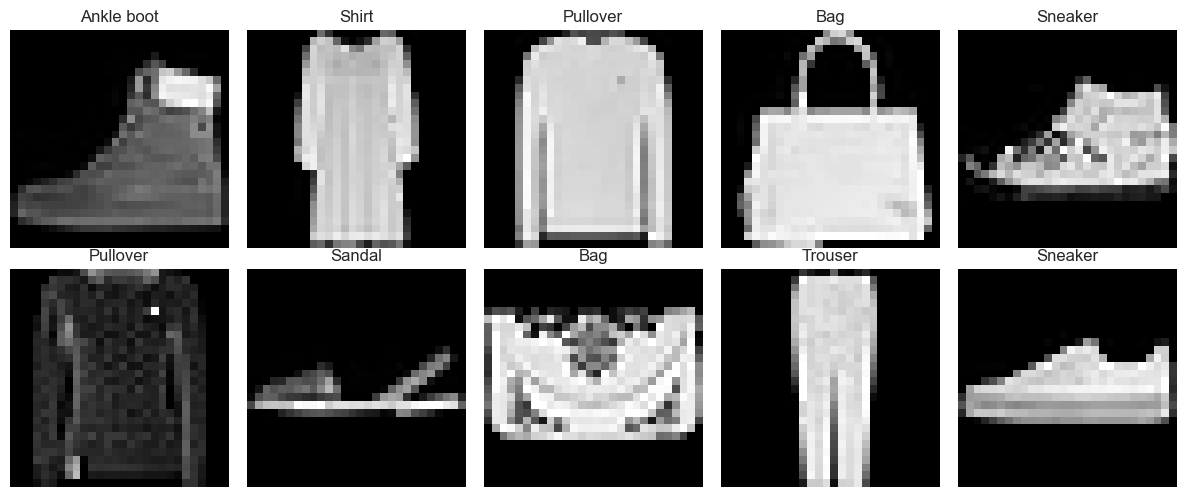

In [20]:
plt.figure(figsize=(12, 5))
random_indices = np.random.choice(len(X_all), 10, replace=False)

for i, idx in enumerate(random_indices):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_all[idx], cmap='gray')
    plt.title(class_names[y_all[idx]])
    plt.axis('off')

plt.tight_layout()
plt.show()

In [22]:
# Check intensity
print(f"Max pixel value before scaling: {X_all.max()}")
print(f"Min pixel value before scaling: {X_all.min()}")

# Scale the feature columns (all columns except 'label')
X_scaled = X_flat / 255.0

print(f"Max pixel value after scaling: {X_scaled.max()}")

Max pixel value before scaling: 255
Min pixel value before scaling: 0
Max pixel value after scaling: 1.0


In [24]:
X_train_val, X_test, Y_train_val, Y_test = train_test_split(
    X_scaled, Y_categorical, test_size=0.2, stratify=y_all, random_state=0
)

# Second split: Split the 30% into half (15% Val, 15% Test)
X_train, X_val, Y_train, Y_val = train_test_split(
    X_train_val, Y_train_val, test_size=0.2, stratify=Y_train_val, random_state=0
)

print(f"Train size: {len(X_train)}")
print(f"Validation size: {len(X_val)}")
print(f"Test size: {len(X_test)}")

Train size: 44800
Validation size: 11200
Test size: 14000


## 2. Building a basic Neural Network

We will start with building a simple NN to have a baseline performance on the dataset.

1. Create a `Sequential` model in Keras.
2. Add an input layer that matches the dimensions of the images, flattened into a 1D vector.
3. Add a hidden layer with 32 units and a non-linear activation function (e.g. `relu`).
4. Add an output layer. What should be the size of the output layer? What activation function should we use for multi-class classification?
5. Compile the model with an appropriate loss function for multi-class classification, a basic optimizer (e.g. `SGD`), and a metric to track (e.g. `accuracy`).
6. Train the model on the training set, using the validation set for monitoring performance. Use a reasonable number of epochs (e.g. 10) and a batch size (e.g. 50).

In [26]:
# 1. Initialize the Sequential model
model = Sequential()

# 2. Add the Input layer (784 pixels because 28x28 = 784)
model.add(Input(shape=(784,)))

# 3. Add a hidden layer (32 units, ReLU activation)
model.add(Dense(units=32, activation='relu'))

# 4. Add the output layer (10 units for 10 classes, Softmax activation)
model.add(Dense(units=10, activation='softmax'))

# 5. Compile the model
model.compile(
    loss='categorical_crossentropy',
    optimizer=SGD(learning_rate=0.01),
    metrics=['accuracy']
)

# Show a summary of the model structure
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │        25,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,450 (99.41 KB)

 Trainable params: 25,450 (99.41 KB)

 Non-trainable params: 0 (0.00 B)

In [27]:
# 6. Train the model
# verbose=1 allows us to see the progress of each epoch
history = model.fit(
    X_train,
    Y_train,
    epochs=10,
    batch_size=50,
    validation_data=(X_val, Y_val),
    verbose=1
)

Epoch 1/10
896/896 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.6901 - loss: 0.9650 - val_accuracy: 0.7771 - val_loss: 0.6672
Epoch 2/10
896/896 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7925 - loss: 0.6194 - val_accuracy: 0.8095 - val_loss: 0.5686
Epoch 3/10
896/896 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8116 - loss: 0.5537 - val_accuracy: 0.8257 - val_loss: 0.5245
Epoch 4/10
896/896 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8220 - loss: 0.5180 - val_accuracy: 0.8337 - val_loss: 0.4954
Epoch 5/10
896/896 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8293 - loss: 0.4951 - val_accuracy: 0.8338 - val_loss: 0.4859
Epoch 6/10
896/896 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8332 - loss: 0.4800 - val_accuracy: 0.8392 - val_loss: 0.4696
Epoch 7/10
896/896 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8379 - loss: 0.4671 - val_accuracy: 0.8423 - val_loss: 0.4582
Epoch 8/10
896/896 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8409 - loss: 0.4554 - val_accuracy: 0.

## 3. Hyperparameter Tuning and Regularization

Using the basic model we built in the previous step, we can now experiment with different hyperparameters and regularization techniques to improve performance.


1. Evaluate the training and validation accuracy of the basic model. Is it underfitting, overfitting, or just right?
2. Try to add a second hidden layer with a different number of units (e.g. 64) and see how it affects performance, if at all.
3. Experiment with different activation functions (e.g. `tanh`, `sigmoid`) in the hidden layers and observe the impact on training and validation accuracy.
4. Is the model overfitting? If so, try adding regularization techniques such as Dropout or regularization (L1/L2) to the hidden layers and see if it helps.
5. Try changing the optimizer to `Adam` and see if it improves convergence and final accuracy compared to `SGD`. Try tuning the learning rate as well.

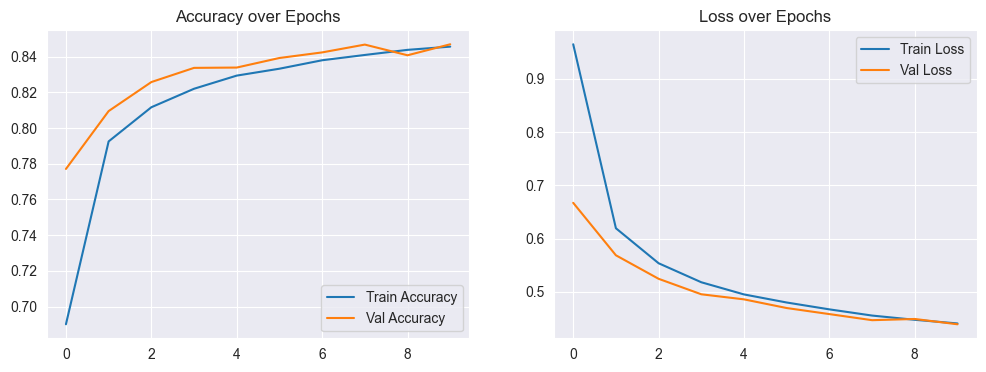

In [28]:
def plot_history(history):
    plt.figure(figsize=(12, 4))

    # Plot Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Val Accuracy')
    plt.title('Accuracy over Epochs')
    plt.legend()

    # Plot Loss
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title('Loss over Epochs')
    plt.legend()
    plt.show()

plot_history(history)

In [30]:
model_tuned = Sequential([
    Input(shape=(784,)),
    # Hidden Layer 1: 128 units, tanh activation, and L2 regularization
    Dense(128, activation='tanh', kernel_regularizer=regularizers.l2(0.001)),
    Dropout(0.2), # Prevents overfitting

    # Hidden Layer 2: 64 units
    Dense(64, activation='tanh'),
    Dropout(0.2),

    # Output Layer
    Dense(10, activation='softmax')
])

In [32]:
custom_adam = Adam(learning_rate=0.001)

model_tuned.compile(
    optimizer=custom_adam,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train for longer (20 epochs) to see the full effect of the tuning
history_tuned = model_tuned.fit(
    X_train, Y_train,
    epochs=20,
    batch_size=64,
    validation_data=(X_val, Y_val),
    verbose=1
)

Epoch 1/20
700/700 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7881 - loss: 0.7567 - val_accuracy: 0.8390 - val_loss: 0.5691
Epoch 2/20
700/700 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8279 - loss: 0.5869 - val_accuracy: 0.8452 - val_loss: 0.5261
Epoch 3/20
700/700 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8351 - loss: 0.5457 - val_accuracy: 0.8411 - val_loss: 0.5226
Epoch 4/20
700/700 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8381 - loss: 0.5230 - val_accuracy: 0.8496 - val_loss: 0.4844
Epoch 5/20
700/700 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8401 - loss: 0.5150 - val_accuracy: 0.8448 - val_loss: 0.4885
Epoch 6/20
700/700 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8402 - loss: 0.5081 - val_accuracy: 0.8511 - val_loss: 0.4661
Epoch 7/20
700/700 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8440 - loss: 0.4998 - val_accuracy: 0.8446 - val_loss: 0.4858
Epoch 8/20
700/700 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8439 - loss: 0.4937 - val_accuracy: 0.

Making the model more complicated did not significantly improve the accuracy of the model. While the accuracy is stable at 0.85, the fact that it is equal for training and validation set indicates that the model is not overfitting. This results in a model that generalizes well to unseen data. The regularization techniques (L2 and Dropout) likely helped prevent overfitting, allowing the model to maintain similar performance on both the training and validation sets. The use of the Adam optimizer with a tuned learning rate may have also contributed to stable convergence without overfitting. Overall, the model seems to be performing okay.

## 4. Evaluation on Test Set

Now that we have experimented with different architectures and hyperparameters, we can evaluate our best model on the test set.

1. Evaluate the final model on the test set and report the test accuracy.
2. Generate a classification report and confusion matrix to analyze the performance of the model across different classes. Which classes are being predicted well? Which classes are being confused with each other?
3. Visualize some of the misclassified samples from the test set along with their predicted and true labels. What types of errors is the model making? Are there any patterns in the misclassifications (e.g. certain classes being confused with each other)?

In [34]:
# 1. Final Test Evaluation
test_results = model_tuned.evaluate(X_test, Y_test, verbose=0)
print(f"Test Loss: {test_results[0]:.4f}")
print(f"Test Accuracy: {test_results[1]:.4f}")

Test Loss: 0.4567
Test Accuracy: 0.8585


438/438 ━━━━━━━━━━━━━━━━━━━━ 0s 772us/step

Classification Report:
              precision    recall  f1-score   support

 T-shirt/top       0.79      0.86      0.82      1400
     Trouser       0.96      0.98      0.97      1400
    Pullover       0.80      0.76      0.78      1400
       Dress       0.84      0.90      0.87      1400
        Coat       0.71      0.86      0.78      1400
      Sandal       0.94      0.94      0.94      1400
       Shirt       0.77      0.54      0.63      1400
     Sneaker       0.86      0.96      0.91      1400
         Bag       0.97      0.94      0.96      1400
  Ankle boot       0.98      0.85      0.91      1400

    accuracy                           0.86     14000
   macro avg       0.86      0.86      0.86     14000
weighted avg       0.86      0.86      0.86     14000



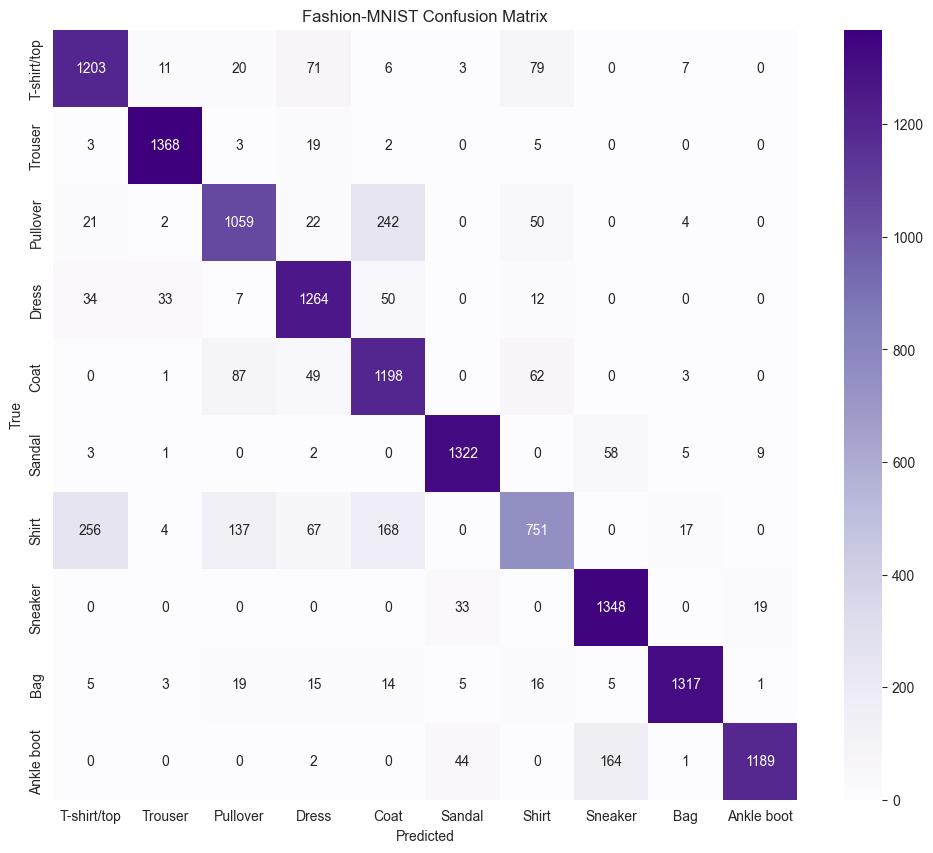

In [36]:
# Get predictions
test_probs = model_tuned.predict(X_test)
test_preds = np.argmax(test_probs, axis=1)
test_labels = np.argmax(Y_test, axis=1)

# Generate Report
print("\nClassification Report:")
print(classification_report(test_labels, test_preds, target_names=list(class_names.values())))

# Generate and Plot Confusion Matrix
cm = confusion_matrix(test_labels, test_preds)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=class_names.values(), yticklabels=class_names.values())
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Fashion-MNIST Confusion Matrix')
plt.show()

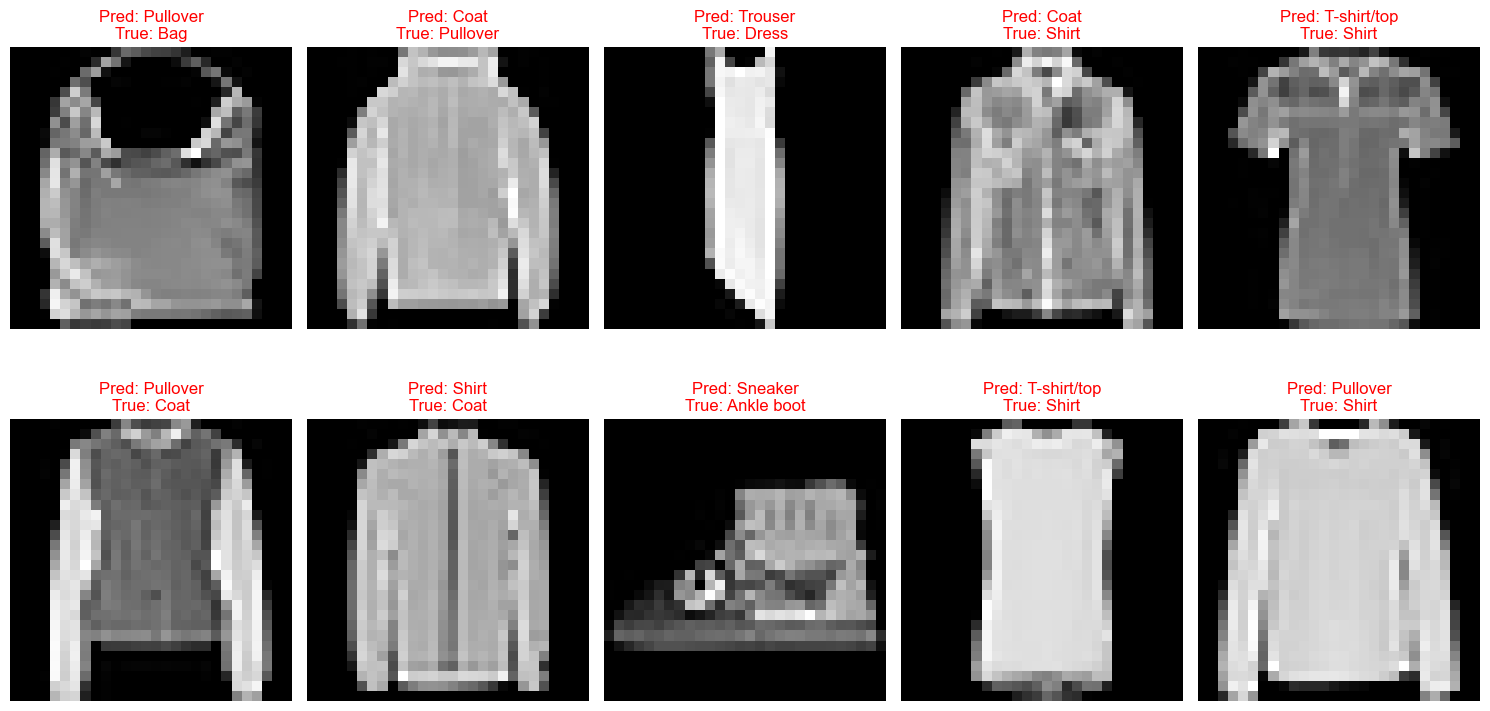

In [37]:
# Find indices where prediction != actual label
mis_idxs = np.where(test_preds != test_labels)[0]

plt.figure(figsize=(15, 8))
for i, idx in enumerate(mis_idxs[:10]):
    plt.subplot(2, 5, i + 1)

    # Reshape back to 28x28 for plotting
    img = X_test[idx].reshape(28, 28)

    plt.imshow(img, cmap='gray')
    plt.title(f"Pred: {class_names[test_preds[idx]]}\nTrue: {class_names[test_labels[idx]]}", color='red')
    plt.axis('off')

plt.tight_layout()
plt.show()

There seem to be two clusters of misclassification: Sneaker - Sandal - Ankle boot and T-shit/top - Shirt - Pullover - Dress - Coat. These categories are in real life very close to each other and in the low resolution of 28x28 might only differ by a few pixels. The errors the model makes seem to be logical and those that a human might be likely to make.